In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO

print("Packages imported!")

Packages imported!


In the first part of the code, we simply use pandas to gather the data needed from the 3 files. Then, we use matplotlib to generate the desired scatter plot.

In [5]:
# Reading the class.tsv file to get the label of each sample
class_labels = pd.read_csv('data/class.tsv', sep='\t', header=None)
labels = class_labels[0].values

# Determining the colors for the labels
colors = ['black' if label == 0 else 'red' for label in labels]

# Reading the columns.tsv file which contains ID to gene name mapping
with gzip.open('data/columns.tsv.gz', 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]
from io import StringIO
filtered_content = StringIO(''.join(lines))
gene_mapping = pd.read_csv(filtered_content, sep='\t')

# Finding the IDs for XBP1 and GATA3
xbp1_id = gene_mapping[gene_mapping['GeneSymbol'] == 'XBP1']['ID'].values[0]
print("XBP1 ID:", xbp1_id) # Matches the expected value of 4404
gata3_id = gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0]
print("GATA3 ID:", gata3_id)

# Reading the filtered.tsv file which contains the expression data
with gzip.open('data/filtered.tsv.gz', 'rt') as f:
    expression_data = pd.read_csv(f, sep='\t')
expression_data.columns = expression_data.columns.astype(str)
expression_data.columns = expression_data.columns.str.strip()

# Extracting the expression data for XBP1 and GATA3
xbp1_expression = expression_data[str(xbp1_id)].values
gata3_expression = expression_data[str(gata3_id)].values

XBP1 ID: 4404
GATA3 ID: 4359


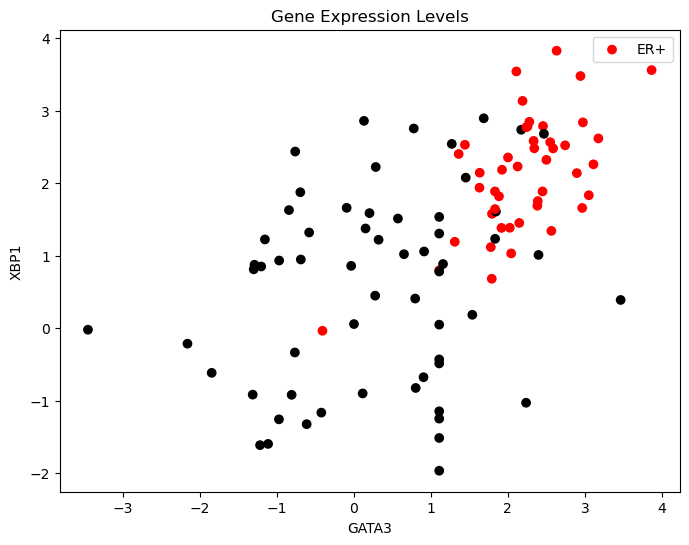

In [6]:
# Plotting the scatter plot of gene expression

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors)
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Gene Expression Levels')
plt.legend(['ER+', 'ER-'], loc='upper right')
plt.show()

Principal Component Analysis (PCA) is a dimensionality reduction technique, where we select the *important* dimensions for simpler analysis and/or visualisation. We do so by selecting the independent dimensions having highest variances and very low covariance with each other. To perform PCA on a dataset, in the form of a matrix $A$, where a column represents a feature, we first calculate $A^T \cdot A$. The first $k$ principal components are the first $k$ eigenvectors when sorted in the descending order of corresponding eigenvalues.

In [7]:
# Defining the PCA function that uses numpy functions to do the linear algebra
def PCA(X):
    X_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    return sorted_eigenvalues, sorted_eigenvectors, X_centered

In this section, we are also concerned with the projection of a two-dimensional dataset on a one-dimensional component. This is nothing but the matrix multiplication of the principal component vector and the original matrix.

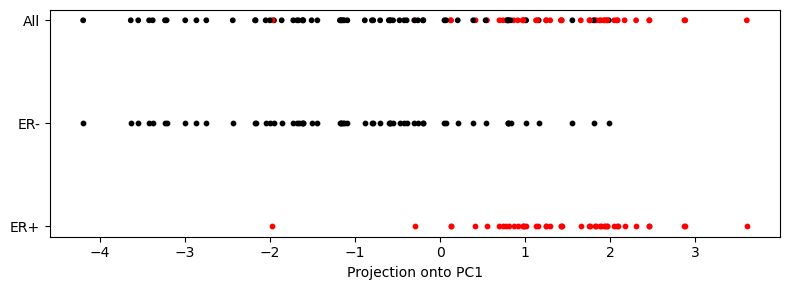

In [ ]:
X = np.column_stack((gata3_expression, xbp1_expression))

# Performing PCA on the expression data
eigenvalues, eigenvectors, X_centered = PCA(X)
pc1 = eigenvectors[:, 0]

# Projecting the data onto the first principal component
projection_pc1 = np.dot(X_centered, pc1)
if np.mean(projection_pc1[labels == 1]) < np.mean(projection_pc1[labels == 0]):
    projection_pc1 = -projection_pc1

er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

y_all = np.full_like(projection_pc1, 2)
y_er_neg = np.full_like(er_neg_pc1, 1)
y_er_pos = np.full_like(er_pos_pc1, 0)

plt.figure(figsize=(8, 3))

# Plot all groups on the same axis with different y values
plt.scatter(projection_pc1, y_all, c=colors, s=10, label='All')
plt.scatter(er_neg_pc1, y_er_neg, c='black', s=10, label='ER-')
plt.scatter(er_pos_pc1, y_er_pos, c='red', s=10, label='ER+')

# Formatting
plt.yticks([0, 1, 2], ['ER+', 'ER-', 'All'])
plt.xlabel('Projection onto PC1')
plt.tight_layout()
plt.show()